# Tutorial: Generator Mapping Check

This notebook helps you visually verify whether topological generators map back to the expected geometric structure in your original data.

Goal in this run:
- Generate a synthetic noisy ring (known 1D hole)
- Compute persistence + generator mappings
- Highlight one selected generator on the original points
- Interactively click persistence points and inspect their mapped geometry
        


## What You Should See

For a noisy ring, the most persistent H1 generator should align with edges around the loop (not random local edges).

If the mapping looks noisy or fragmented:
- Increase sample size
- Reduce noise
- Compare multiple generator indices (not just top-1)
        


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

# Make local package import work when running notebook from repo root.
repo_root = Path.cwd()
src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from tda_toolkit.generators import (
    compute_point_cloud_generator_mappings,
    explore_point_cloud_generators,
    plot_point_cloud_generator_mapping,
    select_generator_mapping,
)
from tda_toolkit.persistence import plot_persistence_diagram

rng = np.random.default_rng(42)
print("Setup complete")
        


Setup complete


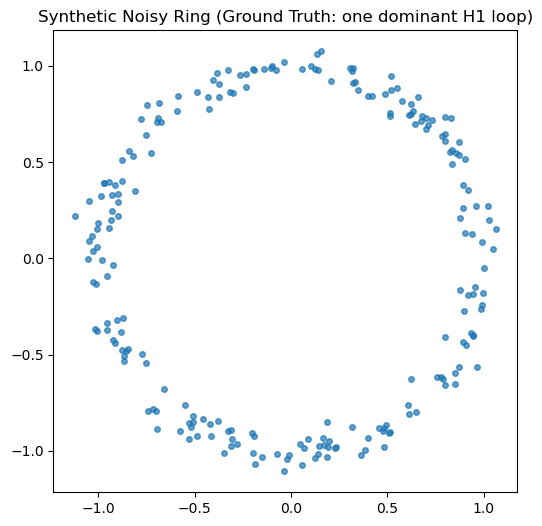

In [2]:
# Step 1: synthetic data with a known 1D hole.
n_points = 220
angles = rng.uniform(0, 2 * np.pi, size=n_points)
radii = 1.0 + 0.05 * rng.standard_normal(n_points)
X = np.column_stack([radii * np.cos(angles), radii * np.sin(angles)])

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(X[:, 0], X[:, 1], s=16, alpha=0.7)
ax.set_title("Synthetic Noisy Ring (Ground Truth: one dominant H1 loop)")
ax.set_aspect("equal")
plt.show()
        


Found 22 finite H1 generator mappings


/opt/homebrew/anaconda3/lib/python3.13/site-packages/gudhi/persistence_graphical_tools.py:129: UserWarning: usetex mode requires TeX.
  warnings.warn("usetex mode requires TeX.")


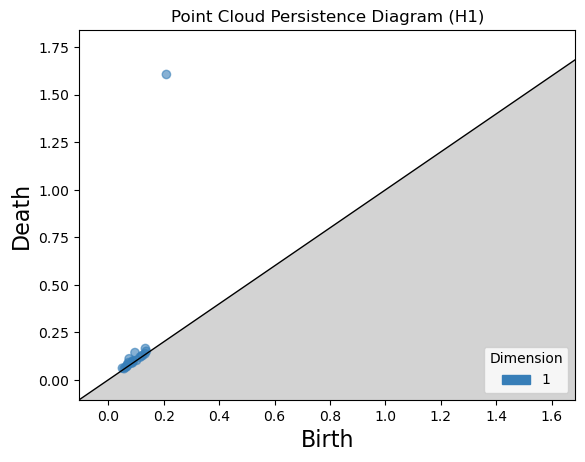

In [3]:
# Step 2: compute persistence + generator mappings.
try:
    result, mappings = compute_point_cloud_generator_mappings(X, dim=1, max_dim=2)
except ImportError as e:
    raise RuntimeError(
        "Gudhi is required for this notebook. Install extras with: pip install -e .[persistence]"
    ) from e

print(f"Found {len(mappings)} finite H1 generator mappings")

# Optional diagram view from Gudhi.
plot_persistence_diagram(result.complex_obj, dimension=1, title="Point Cloud Persistence Diagram (H1)")
        


In [4]:
# Step 3: inspect top generators by persistence.
rows = []
for i, m in enumerate(mappings[:10]):
    rows.append({
        "rank": i,
        "original_pair_index": m.pair_index,
        "birth": round(m.birth, 4),
        "death": round(m.death, 4),
        "persistence": round(m.persistence, 4),
        "num_vertices": len(m.vertices),
        "num_edges": len(m.edges),
    })

for row in rows:
    print(row)
        


{'rank': 0, 'original_pair_index': 240, 'birth': 0.2098, 'death': 1.6069, 'persistence': 1.397, 'num_vertices': 36, 'num_edges': 36}
{'rank': 1, 'original_pair_index': 236, 'birth': 0.0964, 'death': 0.1436, 'persistence': 0.0472, 'num_vertices': 9, 'num_edges': 9}
{'rank': 2, 'original_pair_index': 221, 'birth': 0.0754, 'death': 0.1111, 'persistence': 0.0358, 'num_vertices': 7, 'num_edges': 7}
{'rank': 3, 'original_pair_index': 238, 'birth': 0.134, 'death': 0.165, 'persistence': 0.031, 'num_vertices': 6, 'num_edges': 6}
{'rank': 4, 'original_pair_index': 202, 'birth': 0.0729, 'death': 0.0907, 'persistence': 0.0178, 'num_vertices': 6, 'num_edges': 6}
{'rank': 5, 'original_pair_index': 237, 'birth': 0.1375, 'death': 0.1503, 'persistence': 0.0128, 'num_vertices': 4, 'num_edges': 4}
{'rank': 6, 'original_pair_index': 189, 'birth': 0.0694, 'death': 0.0812, 'persistence': 0.0117, 'num_vertices': 4, 'num_edges': 4}
{'rank': 7, 'original_pair_index': 210, 'birth': 0.0881, 'death': 0.0993, 'per

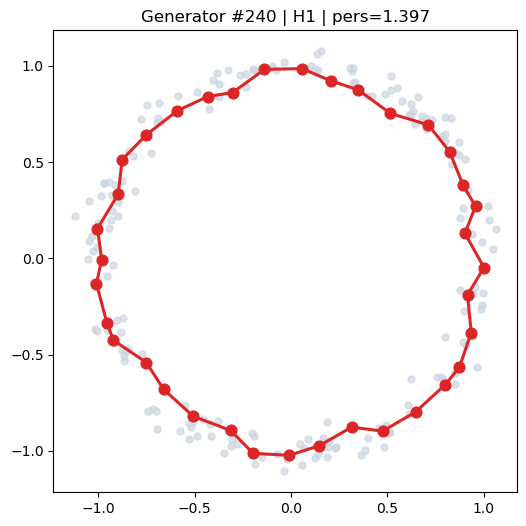

In [5]:
# Step 4: static visualization for a selected generator rank.
selected_rank = 0  # change this to compare different generators
selected = select_generator_mapping(mappings, pair_index=selected_rank)

fig, ax = plt.subplots(figsize=(6, 6))
plot_point_cloud_generator_mapping(X, selected, ax=ax)
ax.set_aspect("equal")
plt.show()
        


In [ ]:
# Step 5: interactive explorer.
# Slider-based browser that you can change the rank of generators to visualize.
from tda_toolkit.generators import browse_point_cloud_generators
browse_point_cloud_generators(X, mappings)
        


## Interpretation Checklist

A good mapping sanity check usually shows:
- Top persistence generator tracing the global ring structure
- Lower persistence generators corresponding to local/noisy structures

Next useful variations:
1. Replace the ring with your own point cloud data
2. Try `dim=0` to inspect connected-component events
3. Compare with scalar-field mapping in CLI: `tda-toolkit generator-field ...`
        
